<a href="https://colab.research.google.com/github/RyanSVargas/Quant-Finance-Research/blob/main/05_Factor_Modeling/05_Alpha_Factor_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install pandas_datareader -q
import pandas_datareader.data as web
import yfinance as yf
import pandas as pd
import statsmodels.api as sm
import datetime

In [16]:
import pandas_datareader.data as web
import yfinance as yf
import pandas as pd
import statsmodels.api as sm
import numpy as np

# --- STEP 1: GET FAMA-FRENCH DATA ---
# We force the index to be 'Month End' timestamps
ff_dict = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start='2020-01-01')
factors = ff_dict[0].copy()
factors.index = factors.index.to_timestamp(freq='M')
factors = factors / 100

print(f"Fama-French Data Loaded: {len(factors)} months")

# --- STEP 2: GET PORTFOLIO DATA (The Fix) ---
tickers = ['BTC-USD', 'ETH-USD', 'SOL-USD', 'NVDA', 'TSLA', 'AAPL', 'JPM', 'GLD', 'USO']

# auto_adjust=True means 'Close' is already adjusted. We grab 'Close'.
data = yf.download(tickers, start='2020-01-01', progress=False, auto_adjust=True)['Close']

# Resample to Month End ('ME') to match Fama-French
monthly_prices = data.resample('ME').last()
monthly_rets = monthly_prices.pct_change().dropna()

# Create Equal Weighted Portfolio
weights = np.array([1/len(tickers)] * len(tickers))
port_returns = monthly_rets.dot(weights)

print(f"Portfolio Data Loaded: {len(port_returns)} months")

# --- STEP 3: STRICT MERGE ---
# Merge on Date Index
full_data = pd.merge(port_returns.rename('Portfolio'), factors, left_index=True, right_index=True, how='inner')

print(f"Merged Data Points for Regression: {len(full_data)}")

# --- STEP 4: RUN REGRESSION ---
if len(full_data) > 0:
    full_data['Excess_Ret'] = full_data['Portfolio'] - full_data['RF']

    X = full_data[['Mkt-RF', 'SMB', 'HML']]
    X = sm.add_constant(X)
    y = full_data['Excess_Ret']

    model = sm.OLS(y, X).fit()
    print("\n--- ALPHA GENERATION RESULTS ---")
    print(model.summary())
else:
    print("Error: No overlapping dates found.")

/tmp/ipython-input-4293999090.py:9: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_dict = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start='2020-01-01')
/tmp/ipython-input-4293999090.py:9: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_dict = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start='2020-01-01')


Fama-French Data Loaded: 72 months
Portfolio Data Loaded: 70 months
Merged Data Points for Regression: 68

--- ALPHA GENERATION RESULTS ---
                            OLS Regression Results                            
Dep. Variable:             Excess_Ret   R-squared:                       0.538
Model:                            OLS   Adj. R-squared:                  0.517
Method:                 Least Squares   F-statistic:                     24.89
Date:                Fri, 13 Feb 2026   Prob (F-statistic):           8.65e-11
Time:                        15:09:08   Log-Likelihood:                 70.259
No. Observations:                  68   AIC:                            -132.5
Df Residuals:                      64   BIC:                            -123.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025    

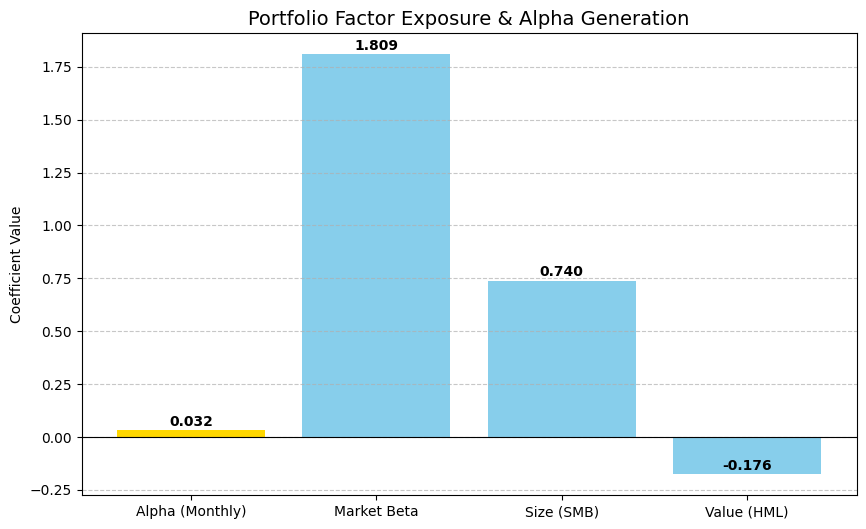

In [17]:
import matplotlib.pyplot as plt

# Extracting coefficients for the chart
factors_names = ['Alpha (Monthly)', 'Market Beta', 'Size (SMB)', 'Value (HML)']
coeffs = [model.params['const'], model.params['Mkt-RF'], model.params['SMB'], model.params['HML']]

plt.figure(figsize=(10, 6))
colors = ['gold' if x == model.params['const'] else 'skyblue' for x in coeffs]
plt.bar(factors_names, coeffs, color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Portfolio Factor Exposure & Alpha Generation', fontsize=14)
plt.ylabel('Coefficient Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for i, v in enumerate(coeffs):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')

plt.show()